In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('programs/ectoderm_programs.csv')

In [3]:
print(df.head(2))

           cell_type stage germ_layer    3         4    5    9   12   14  \
0  Amniotic ectoderm  E8.5   Ectoderm  0.0  0.000000  0.0  0.0  0.0  0.0   
1  Amniotic ectoderm  E9.0   Ectoderm  0.0  0.333705  0.0  0.0  0.0  0.0   

        15  ...   48   49   50   54        56   57   59   60   66   67  
0  0.00000  ...  0.0  0.0  0.0  0.0  0.431065  0.0  0.0  0.0  0.0  0.0  
1  0.58092  ...  0.0  0.0  0.0  0.0  0.460847  0.0  0.0  0.0  0.0  0.0  

[2 rows x 39 columns]


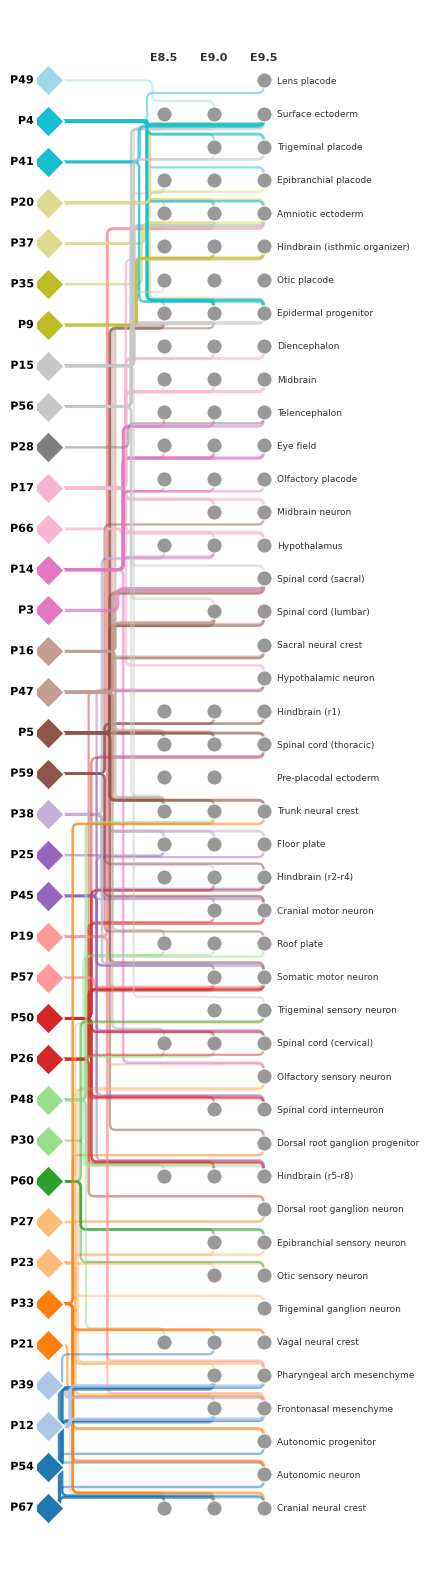

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
from scipy.sparse.csgraph import laplacian
from scipy.linalg import eigh
from collections import defaultdict

# == Parameters ================================================================
FIG_SIZE = (18, 16)
GRID_SPACING_X = 1.5
GRID_SPACING_Y = 1.0
PROG_COL_OFFSET = 3.5        # gap between leftmost grid col and program col

EDGE_ALPHA_MIN = 0.20
EDGE_ALPHA_MAX = 0.88
EDGE_LW_MIN = 0.9
EDGE_LW_MAX = 2.8
EDGE_WEIGHT_THRESH = 0.0

PARALLEL_OFFSET = 0.045      # perpendicular shift between parallel lines
CORRIDOR_FRAC = 0.38         # fraction of GRID_SPACING_Y for corridor offset
CORNER_RADIUS = 0.18
CORNER_ARC_PTS = 10

TRUNK_MARGIN_INNER = 0.35    # gap trunk → grid edge
TRUNK_MARGIN_OUTER = 0.35    # gap trunk → program column

GRID_NODE_SIZE = 120
PROG_NODE_SIZE = 260
PROG_LABEL_FONTSIZE = 8
STAGE_LABEL_FONTSIZE = 8
CT_LABEL_FONTSIZE = 6.5
LABEL_OFFSET = 0.42

GERM_LAYER_COLORS = {
    "ectoderm":  "#4C9BE8",
    "mesoderm":  "#E86C4C",
    "endoderm":  "#5DC75D",
}
DEFAULT_GL_COLOR = "#999999"

# == Data prep =================================================================
meta_cols = ["cell_type", "stage", "germ_layer"]
program_cols = [c for c in df.columns if c not in meta_cols]

stage_order = sorted(df["stage"].unique(),
                     key=lambda s: float(s.replace("E", "")))
cell_types_unsorted = sorted(df["cell_type"].unique())

n_rows = len(cell_types_unsorted)
n_cols = len(stage_order)
n_programs = len(program_cols)

ct_prog = np.zeros((n_rows, n_programs))
for idx, ct in enumerate(cell_types_unsorted):
    sub = df[df["cell_type"] == ct]
    ct_prog[idx] = sub[program_cols].max(axis=0).values

# -- Ordering ------------------------------------------------------------------
def spectral_order(W):
    norms = np.linalg.norm(W, axis=1, keepdims=True)
    norms = np.where(norms == 0, 1, norms)
    S = (W / norms) @ (W / norms).T
    np.clip(S, 0, None, out=S)
    np.fill_diagonal(S, 0)
    L = laplacian(S, normed=False)
    _, vecs = eigh(L)
    return np.argsort(vecs[:, 1])

def barycentric_sort(W, fixed_order):
    n = W.shape[0]
    positions = np.arange(len(fixed_order), dtype=float)
    bary = np.zeros(n)
    for i in range(n):
        weights = W[i, fixed_order]
        total = weights.sum()
        bary[i] = np.dot(weights, positions) / total if total > 0 else positions.mean()
    return np.argsort(bary)

ct_perm = spectral_order(ct_prog)
for _ in range(8):
    prog_perm = barycentric_sort(ct_prog.T, ct_perm)
    ct_perm   = barycentric_sort(ct_prog,   prog_perm)

cell_types = [cell_types_unsorted[i] for i in ct_perm]
program_cols_ordered = [program_cols[i] for i in prog_perm]

ct_to_row    = {ct: i for i, ct in enumerate(cell_types)}
stage_to_col = {st: j for j, st in enumerate(stage_order)}

# == Layout ====================================================================
grid_xs = np.arange(n_cols) * GRID_SPACING_X
grid_ys = np.arange(n_rows) * GRID_SPACING_Y
grid_xs -= grid_xs.mean()
grid_ys -= grid_ys.mean()

grid_pos = {}
for _, row in df.iterrows():
    ct, st = row["cell_type"], row["stage"]
    grid_pos[(ct, st)] = (grid_xs[stage_to_col[st]], grid_ys[ct_to_row[ct]])

# ---- Programs on the LEFT ----------------------------------------------------
prog_x_base = grid_xs.min() - PROG_COL_OFFSET
prog_ys_arr = np.linspace(grid_ys.min(), grid_ys.max(), n_programs)
prog_pos = {pc: (prog_x_base, prog_ys_arr[i])
             for i, pc in enumerate(program_cols_ordered)}

# == Trunk channels (between programs and grid, programs on left) ==============
trunk_zone_L = prog_x_base  + TRUNK_MARGIN_OUTER   # right of programs
trunk_zone_R = grid_xs.min() - TRUNK_MARGIN_INNER   # left of grid

prog_com_y = {}
for pc in program_cols_ordered:
    ws, ys_list = [], []
    for _, row in df.iterrows():
        w = row[pc]
        if w > EDGE_WEIGHT_THRESH:
            ys_list.append(grid_ys[ct_to_row[row["cell_type"]]])
            ws.append(w)
    if ws:
        ws = np.array(ws)
        prog_com_y[pc] = np.average(ys_list, weights=ws)
    else:
        prog_com_y[pc] = prog_pos[pc][1]

progs_by_com = sorted(program_cols_ordered, key=lambda p: prog_com_y[p])
trunk_xs_arr = np.linspace(trunk_zone_L, trunk_zone_R, n_programs)
prog_trunk_x = {pc: trunk_xs_arr[i] for i, pc in enumerate(progs_by_com)}

# == Corridor routing ==========================================================
# Each edge's horizontal run travels in a *corridor* between rows, not through
# the row itself.  Direction: approach from above if the program y >= target row
# y, else from below.  This keeps horizontals out of the node line.

CORRIDOR_OFFSET = GRID_SPACING_Y * CORRIDOR_FRAC

# Pre-compute direction per (program, row) — we need the most common direction
# across stages for a given (program, row) pair so all edges to the same row
# from the same program share a corridor.
edge_direction = {}   # (row_idx, pc) → +1 or -1
for pc in program_cols_ordered:
    py = prog_pos[pc][1]
    for r_idx in range(n_rows):
        gy = grid_ys[r_idx]
        edge_direction[(r_idx, pc)] = 1 if py >= gy else -1

# Collect which programs use each corridor for parallel-offset computation
corridor_progs = defaultdict(set)   # (row_idx, direction) → {programs}
for _, row in df.iterrows():
    r = ct_to_row[row["cell_type"]]
    for pc in program_cols_ordered:
        if row[pc] > EDGE_WEIGHT_THRESH:
            d = edge_direction[(r, pc)]
            corridor_progs[(r, d)].add(pc)

corridor_prog_voff = {}   # (row_idx, direction, pc) → small vertical offset
for (r, d), progs in corridor_progs.items():
    ordered = sorted(progs, key=lambda p: prog_trunk_x[p])
    n = len(ordered)
    for i, pc in enumerate(ordered):
        corridor_prog_voff[(r, d, pc)] = (i - (n - 1) / 2.0) * PARALLEL_OFFSET

def _quad_arc(a, corner, b, n_pts):
    t = np.linspace(0, 1, n_pts)[:, None]
    a, corner, b = map(np.asarray, (a, corner, b))
    return (1 - t)**2 * a + 2 * (1 - t) * t * corner + t**2 * b

def rounded_ortho(waypoints, radius=CORNER_RADIUS, n_arc=CORNER_ARC_PTS):
    pts = [np.asarray(p, dtype=float) for p in waypoints]
    if len(pts) < 3:
        return np.array(pts)
    out = [pts[0].copy()]
    for i in range(1, len(pts) - 1):
        p_prev, p_cur, p_next = pts[i - 1], pts[i], pts[i + 1]
        d1, d2 = p_cur - p_prev, p_next - p_cur
        L1, L2 = np.linalg.norm(d1), np.linalg.norm(d2)
        r = min(radius, L1 / 2.0, L2 / 2.0)
        if r < 1e-8 or L1 < 1e-8 or L2 < 1e-8:
            out.append(p_cur.copy())
            continue
        arc_start = p_cur - (d1 / L1) * r
        arc_end   = p_cur + (d2 / L2) * r
        out.extend(_quad_arc(arc_start, p_cur, arc_end, n_arc).tolist())
    out.append(pts[-1].copy())
    return np.array(out)

gl_map = (df.drop_duplicates("cell_type")
            .set_index("cell_type")["germ_layer"].to_dict())
prog_cmap = plt.cm.tab20
prog_colors = {pc: prog_cmap(i / max(n_programs, 1))
               for i, pc in enumerate(program_cols_ordered)}

# == Draw ======================================================================
fig, ax = plt.subplots(figsize=FIG_SIZE, facecolor="white")
ax.set_aspect("equal")
ax.axis("off")

w_max = df[program_cols].values.max() or 1.0

# ---- edges -------------------------------------------------------------------
for _, row in df.iterrows():
    ct, st = row["cell_type"], row["stage"]
    r  = ct_to_row[ct]
    gx, gy = grid_pos[(ct, st)]

    for pc in program_cols_ordered:
        w = row[pc]
        if w <= EDGE_WEIGHT_THRESH:
            continue

        px, py = prog_pos[pc]
        tx     = prog_trunk_x[pc]
        d      = edge_direction[(r, pc)]
        v_off  = corridor_prog_voff.get((r, d, pc), 0.0)

        corridor_y = gy + d * CORRIDOR_OFFSET + v_off

        # Waypoints:
        #   program -> horiz to trunk -> vert to corridor -> horiz to target col -> vert jog to node
        waypoints = [
            (px, py),
            (tx, py),
            (tx, corridor_y),
            (gx, corridor_y),
            (gx, gy),
        ]

        curve = rounded_ortho(waypoints)

        t     = w / w_max
        alpha = EDGE_ALPHA_MIN + (EDGE_ALPHA_MAX - EDGE_ALPHA_MIN) * t
        lw    = EDGE_LW_MIN   + (EDGE_LW_MAX   - EDGE_LW_MIN)   * t

        ax.plot(curve[:, 0], curve[:, 1],
                color=prog_colors[pc], alpha=alpha, lw=lw,
                solid_capstyle="round", solid_joinstyle="round", zorder=1)

# ---- grid nodes --------------------------------------------------------------
for (ct, st), (x, y) in grid_pos.items():
    gl = gl_map.get(ct, "")
    c  = GERM_LAYER_COLORS.get(gl, DEFAULT_GL_COLOR)
    ax.scatter(x, y, s=GRID_NODE_SIZE, c=c,
               edgecolors="white", linewidths=0.8, zorder=5)

# ---- program nodes + labels (LEFT, label to the left of the diamond) ---------
for pc, (x, y) in prog_pos.items():
    ax.scatter(x, y, s=PROG_NODE_SIZE, c=[prog_colors[pc]],
               edgecolors="white", linewidths=1.2, zorder=5, marker="D")
    ax.text(x - LABEL_OFFSET, y, f"P{pc}", fontsize=PROG_LABEL_FONTSIZE,
            fontweight="bold", ha="right", va="center",
            path_effects=[pe.withStroke(linewidth=3, foreground="white")])

# ---- stage labels (top) ------------------------------------------------------
for st, j in stage_to_col.items():
    ax.text(grid_xs[j], grid_ys.max() + 0.55, st,
            ha="center", va="bottom",
            fontsize=STAGE_LABEL_FONTSIZE, fontweight="bold", color="#333")

# ---- cell-type labels (RIGHT, de-overlapped) ---------------------------------
ct_label_positions = [(ct, grid_ys[ct_to_row[ct]]) for ct in cell_types]
min_gap = 0.28
adjusted = []
for ct, y in ct_label_positions:
    if adjusted and y - adjusted[-1][1] < min_gap:
        y = adjusted[-1][1] + min_gap
    adjusted.append((ct, y))

for ct, y in adjusted:
    ax.text(grid_xs.max() + 0.4, y, ct,
            ha="left", va="center",
            fontsize=CT_LABEL_FONTSIZE, color="#333")

# ---- legend ------------------------------------------------------------------
# legend_handles = [mpatches.Patch(color=c, label=gl)
#                   for gl, c in GERM_LAYER_COLORS.items()]
# ax.legend(handles=legend_handles, loc="lower right", frameon=True,
#           fontsize=8, title="Germ layer", title_fontsize=9)

plt.tight_layout()
plt.show()